In [1]:
!pip install langchain langchain_community

In [2]:
!pip install langchain-groq
from langchain_groq import ChatGroq

In [ ]:
GROQ_API_KEY = "YOUR_GROQ_API_KEY"  # Replace with your actual API key

llm = ChatGroq( 
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
)

In [4]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [5]:
class State(TypedDict):
  message:Annotated[list,add_messages]


In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x79646bb14050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x79646bb14d70>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def chatbot(state:State):
  response=llm.invoke(state['message'])
  return{ 'message':[response]}



In [8]:
graph_builder=StateGraph(State)

In [9]:
graph_builder.add_node("chatbot",chatbot)

In [10]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [11]:
memory=MemorySaver()

In [12]:
graph_app=graph_builder.compile(checkpointer=memory)

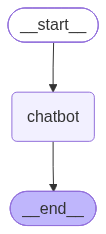

In [13]:
from IPython.display import Image, display

# Render and display the graph
display(Image(graph_app.get_graph().draw_mermaid_png()))


In [14]:
from langchain_core.messages import HumanMessage

In [15]:
config={
    "configurable":{
        "thread_id":"chan_chat"
    }
}
while True:
  input_user=input("Enter your message: ")
  if input_user=="exit":
    break
  result=graph_app.invoke({
      "message":[
          HumanMessage(content=input_user)
      ]
  },
    config=config
  )
  print(result['message'][-1].content)

**Checkpointer persistence** is the practice of storing the state of a running computation (or “checkpoint”) in a durable, long‑term medium so that the work can be resumed later, even after a crash, restart, or planned shutdown.  

Below is a concise overview that covers the *what*, *why*, *how*, and *where* of checkpointer persistence, together with common patterns, pitfalls, and best‑practice recommendations.

---

## 1. Core Definition  

| Term | Meaning |
|------|---------|
| **Checkpoint** | A snapshot of the essential state of a system at a particular point in time. This state is sufficient to restart the computation from that point without re‑doing all prior work. |
| **Checkpointer** | The component (software routine, library, or service) that creates, writes, and later reads those snapshots. |
| **Persistence** | The act of writing the checkpoint to a storage medium that survives process termination, node failure, or power loss (e.g., disk, SSD, distributed file system, objec